Figure saved to: C:\Users\tomos\OneDrive - Ulster University\GlacialExtractionData\scripts\figure_scripts\Figure3\Figure3.png


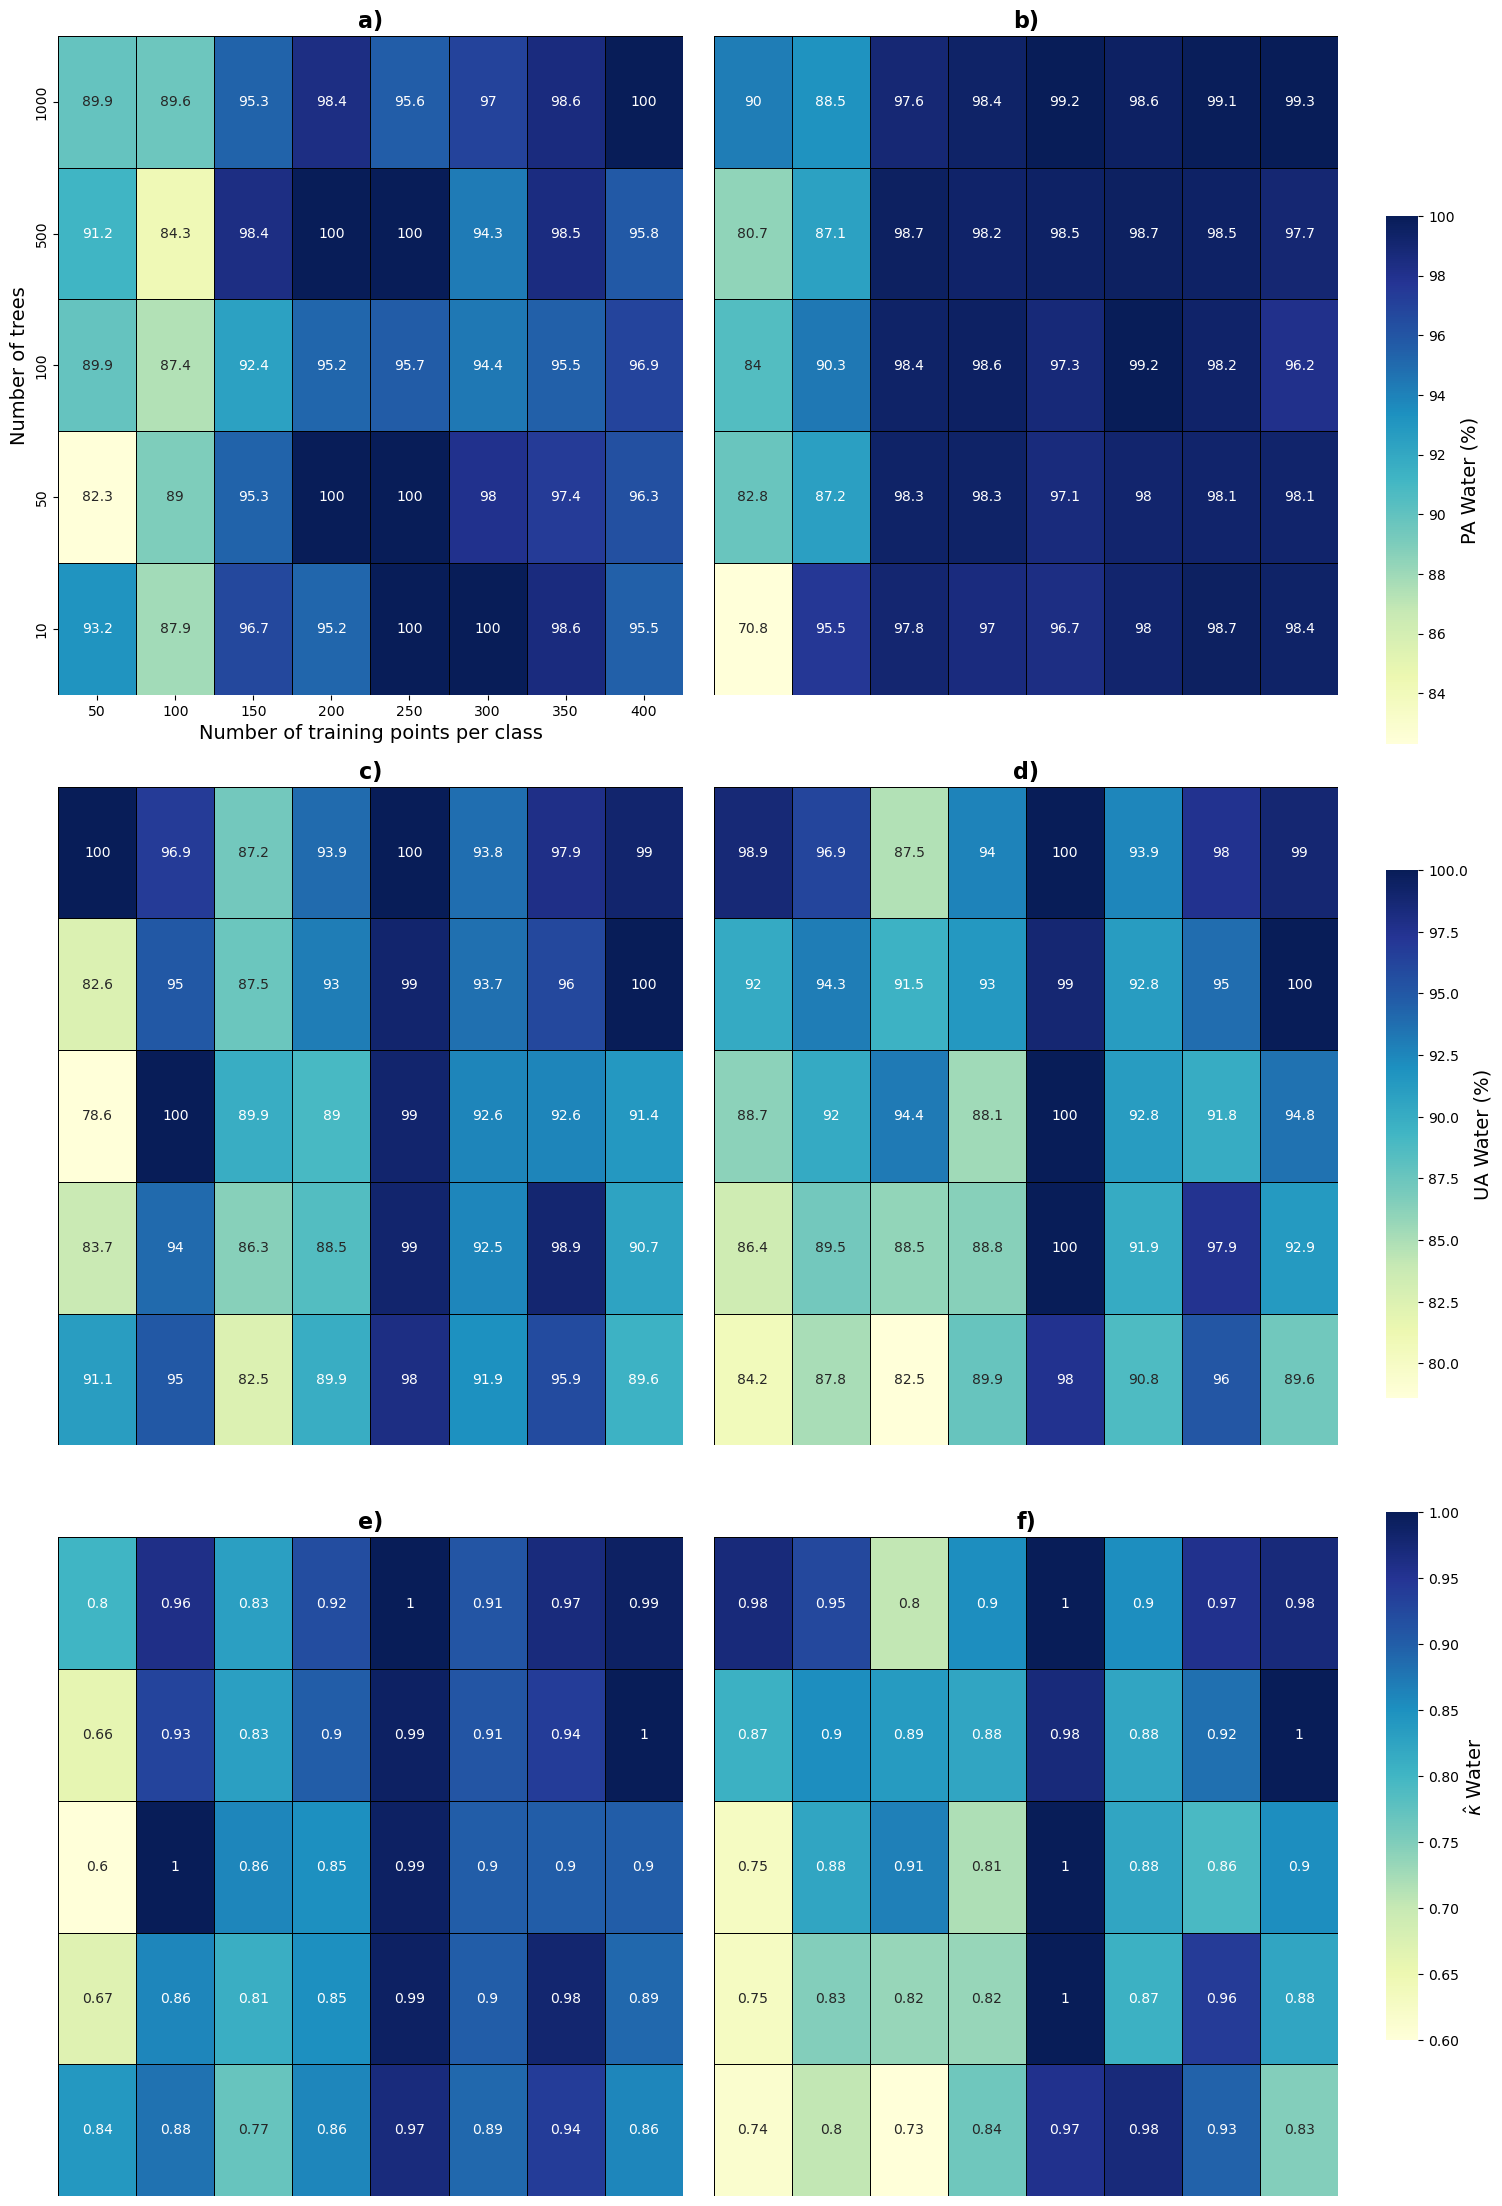

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def format_annotation(val, decimal_places=1):
    """Format numbers to remove trailing .0 if whole number."""
    if pd.isna(val):
        return ""
    formatted = f"{val:.{decimal_places}f}"
    return formatted.rstrip("0").rstrip(".") if "." in formatted else formatted

base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

file_path_wnw = os.path.join(base_dir, "WaterNotWaterResults.csv")
file_path_wc = os.path.join(base_dir, "WaterClassifierResults.csv")
save_path = os.path.join(base_dir, "Figure3.png")

df_wnw = pd.read_csv(file_path_wnw)
df_wc = pd.read_csv(file_path_wc)

heatmap_data_pa_wnw = df_wnw.pivot_table(index="RF", columns="Points", values="PA Water", aggfunc="mean")
heatmap_data_ua_wnw = df_wnw.pivot_table(index="RF", columns="Points", values="UA Water", aggfunc="mean")
heatmap_data_kappa_wnw = df_wnw.pivot_table(index="RF", columns="Points", values="Kappa hat Water", aggfunc="mean")

heatmap_data_pa_wc = df_wc.pivot_table(index="RF", columns="Points", values="PA Water", aggfunc="mean")
heatmap_data_ua_wc = df_wc.pivot_table(index="RF", columns="Points", values="UA Water", aggfunc="mean")
heatmap_data_kappa_wc = df_wc.pivot_table(index="RF", columns="Points", values="Kappa hat Water", aggfunc="mean")

heatmap_data_pa_wnw = heatmap_data_pa_wnw.sort_index(ascending=False)
heatmap_data_ua_wnw = heatmap_data_ua_wnw.sort_index(ascending=False)
heatmap_data_kappa_wnw = heatmap_data_kappa_wnw.sort_index(ascending=False)
heatmap_data_pa_wc = heatmap_data_pa_wc.sort_index(ascending=False)
heatmap_data_ua_wc = heatmap_data_ua_wc.sort_index(ascending=False)
heatmap_data_kappa_wc = heatmap_data_kappa_wc.sort_index(ascending=False)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 24),
    gridspec_kw={"wspace": 0.05, "hspace": 0.14}
)

cbar_ax_pa = fig.add_axes([0.91, 0.655, 0.02, 0.22])
cbar_ax_ua = fig.add_axes([0.91, 0.3825, 0.02, 0.22])
cbar_ax_kappa = fig.add_axes([0.91, 0.115, 0.02, 0.22])

annotations_pa_wnw = heatmap_data_pa_wnw.map(lambda x: format_annotation(x, 1))

sns.heatmap(
    heatmap_data_pa_wnw,
    annot=annotations_pa_wnw,
    fmt="",
    cmap="YlGnBu",
    ax=axes[0, 0],
    cbar=True,
    cbar_ax=cbar_ax_pa,
    cbar_kws={"label": "PA Water (%)"},
    linecolor="black",
    linewidths=0.5
)

axes[0, 0].set_title("a)", fontsize=16, fontweight="bold")
axes[0, 0].set_ylabel("Number of trees", fontsize=14)
axes[0, 0].set_xlabel("Number of training points per class", fontsize=14)

heatmaps = [
    (heatmap_data_pa_wc, axes[0, 1], "b)", None, None, 1),
    (heatmap_data_ua_wnw, axes[1, 0], "c)", cbar_ax_ua, "UA Water (%)", 1),
    (heatmap_data_ua_wc, axes[1, 1], "d)", None, None, 1),
    (heatmap_data_kappa_wnw, axes[2, 0], "e)", cbar_ax_kappa, "$\hat{\kappa}$ Water", 2),
    (heatmap_data_kappa_wc, axes[2, 1], "f)", None, None, 2),
]

for data, ax, title, cbar_ax, cbar_label, decimal_places in heatmaps:
    annotations = data.map(lambda x: format_annotation(x, decimal_places))

    sns.heatmap(
        data,
        annot=annotations,
        fmt="",
        cmap="YlGnBu",
        ax=ax,
        cbar=cbar_ax is not None,
        cbar_ax=cbar_ax,
        cbar_kws={"label": cbar_label} if cbar_label else None,
        linecolor="black",
        linewidths=0.5
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)

cbar_ax_pa.set_ylabel("PA Water (%)", fontsize=14)
cbar_ax_ua.set_ylabel("UA Water (%)", fontsize=14)
cbar_ax_kappa.set_ylabel("$\hat{\kappa}$ Water", fontsize=14)

fig.subplots_adjust(left=0.08, right=0.88, top=0.95, bottom=0.05)

fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
print(f"Figure saved to: {save_path}")

plt.show()
plt.close(fig)